# Ensemble: Frozen ViT-B/16 + DINOv2 ViT-B/14 PatchCore

Max-fusion score ensemble combining:
- **Frozen ViT-B/16** (supervised ImageNet-21k) — strong on global defects (Edge-Ring 0.941, Edge-Loc 0.705)
- **Frozen DINOv2 ViT-B/14 block 9** (DINO self-distillation, 142M images) — strong on local defects (Scratch 0.933)

**No recomputation.** Both models' scores are loaded from saved `.npz` files. The ensemble requires no GPU.

**Method:** each model's scores are min-max normalised to `[0, 1]` independently using the full
observed score range (tune-normal + test-normal + test-defect). The ensemble score is the
element-wise maximum. Threshold is calibrated at `q=0.95` on the ensemble tune-normal scores.

**Control flags (set in the Configuration cell):**
- `DINOV2_BLOCK` — which DINOv2 block sweep run to load (`9` for best Scratch recall, `6` for best overall DINOv2)
- `FORCE_RERUN_UMAP` — set `True` to rerun UMAP, `False` to display saved figure

## Individual model results (for context)

| Model | F1 | AUROC | AUPRC | Scratch | Edge-Ring | Edge-Loc |
|---|---|---|---|---|---|---|
| Frozen ViT-B/16 | 0.595 | 0.956 | 0.671 | 0.727 | 0.941 | 0.705 |
| DINOv2 block 6 | 0.521 | 0.926 | 0.549 | 0.800 | 0.774 | 0.604 |
| DINOv2 block 9 | 0.492 | 0.915 | 0.561 | **0.933** | 0.738 | 0.547 |
| Ensemble (this) | TBD | TBD | TBD | TBD | TBD | TBD |

## Setup

In [1]:
# -- 0. Check dependencies -----------------------------------------------------
import importlib.util, subprocess, sys
for pkg in ['umap']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'umap-learn', '-q'])
print('Dependencies ready')

Dependencies ready


## Imports

In [2]:
# -- 1. Imports ----------------------------------------------------------------
import os, gc, json, random, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, precision_score, recall_score,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

from IPython.display import display, Image as IPImage
print('Imports OK')

Imports OK


## Configuration

Set `DINOV2_BLOCK = 9` for max Scratch recall or `6` for best overall DINOv2 coverage.

In [5]:
# -- 2. Configuration ----------------------------------------------------------
from pathlib import Path

# ── Repo root resolution ──────────────────────────────────────────────────────
cwd = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / 'src' / 'wafer_defect').exists() and (candidate / 'configs').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate repo root containing src/wafer_defect and configs/')

# ── Control flags ─────────────────────────────────────────────────────────────
# Which DINOv2 block sweep to load:
#   9  → best Scratch recall (0.933) — most complementary to ViT-B/16
#   6  → best overall DINOv2 metrics (AUROC 0.926, F1 0.521)
DINOV2_BLOCK     = 9
FORCE_RERUN_UMAP = False   # True → rerun UMAP projection

# ── Data ──────────────────────────────────────────────────────────────────────
METADATA_CSV = str(PROJECT_ROOT / 'data' / 'processed' / 'x224' / 'wm811k' / 'metadata_50k_5pct.csv')
TRAIN_NORMAL_N = 40_000
TUNE_NORMAL_N  =  5_000
TEST_NORMAL_N  =  5_000
TEST_DEFECT_N  =    250

# ── Score file paths ──────────────────────────────────────────────────────────
# Frozen ViT-B/16 baseline (z-scores: keys *_z)
VIT_SCORES_PATH = str(
    PROJECT_ROOT /
    'experiments/anomaly_detection/patchcore/vit_b16/x224'
    '/main/artifacts/patchcore_vit_b16_5pct/main_5pct/results/scores.npz'
)

# DINOv2 block sweep scores (raw distances)
_block_dir = f'block{DINOV2_BLOCK}' if DINOV2_BLOCK == 9 else f'block_{DINOV2_BLOCK}'
DINOV2_SCORES_PATH = str(
    PROJECT_ROOT /
    f'experiments/anomaly_detection/patchcore/dinov2_vit_b14/x224'
    f'/{_block_dir}/artifacts/results/scores.npz'
)

# ── Threshold ─────────────────────────────────────────────────────────────────
THRESHOLD_QUANTILE = 0.95

# ── Artifact paths ────────────────────────────────────────────────────────────
ARTIFACT_DIR = str(
    PROJECT_ROOT /
    f'experiments/anomaly_detection/patchcore/dinov2_vit_b14/x224'
    f'/ensemble_block{DINOV2_BLOCK}/artifacts'
)
PLOTS_DIR   = os.path.join(ARTIFACT_DIR, 'plots')
RESULTS_DIR = os.path.join(ARTIFACT_DIR, 'results')

SCORES_EXPORT_PATH  = os.path.join(RESULTS_DIR, 'scores.npz')
METRICS_EXPORT_PATH = os.path.join(RESULTS_DIR, 'evaluation_metrics.json')
UMAP_PNG_PATH       = os.path.join(PLOTS_DIR,   'umap_test_embeddings.png')
UMAP_CSV_PATH       = os.path.join(RESULTS_DIR, 'umap_test_embeddings.csv')

for d in [PLOTS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Project root    : {PROJECT_ROOT}')
print(f'ViT-B/16 scores : {VIT_SCORES_PATH}')
print(f'DINOv2 scores   : {DINOV2_SCORES_PATH}')
print(f'DINOv2 block    : {DINOV2_BLOCK}')
print(f'Threshold       : q={THRESHOLD_QUANTILE}')
print(f'Artifacts       : {ARTIFACT_DIR}')

Project root    : C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8
ViT-B/16 scores : C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\vit_b16\x224\main\artifacts\patchcore_vit_b16_5pct\main_5pct\results\scores.npz
DINOv2 scores   : C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\dinov2_vit_b14\x224\block9\artifacts\results\scores.npz
DINOv2 block    : 9
Threshold       : q=0.95
Artifacts       : C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\dinov2_vit_b14\x224\ensemble_block9\artifacts


## Load Dataset

Only the test-defect split is needed to recover per-class failure labels. No model inference runs here.

In [6]:
# -- 3. Load dataset (labels only) --------------------------------------------
df = pd.read_csv(METADATA_CSV).copy()

df['failure_label'] = df['defect_type'].astype(str).str.strip()
df['is_anomaly'] = df['is_anomaly'].astype(int)

test_defect_df = (
    df[(df['split'] == 'test') & (df['is_anomaly'] == 1)]
    .head(TEST_DEFECT_N)
    .copy()
)

defect_class_labels = test_defect_df['failure_label'].values
print(f'Test defect class labels recovered: {len(defect_class_labels)} samples')
print(pd.Series(defect_class_labels).value_counts().to_string())


Test defect class labels recovered: 250 samples
Edge-Ring    84
Edge-Loc     53
Center       50
Loc          34
Scratch      15
Donut         7
Random        5
Near-full     2


## Load Scores

Frozen ViT-B/16 scores are stored as z-scores (`(raw - train_mu) / train_std`). DINOv2 scores are raw kNN distances. Both are normalised to `[0, 1]` independently before fusion.

In [7]:
# -- 4. Load scores from disk --------------------------------------------------

# ── Frozen ViT-B/16 (z-scores) ────────────────────────────────────────────────
with np.load(VIT_SCORES_PATH) as vit_npz:
    vit_tune   = vit_npz['tune_normal_scores_z'].astype(np.float64)
    vit_normal = vit_npz['test_normal_scores_z'].astype(np.float64)
    vit_defect = vit_npz['test_defect_scores_z'].astype(np.float64)

# ── DINOv2 (raw kNN distances) ────────────────────────────────────────────────
with np.load(DINOV2_SCORES_PATH) as d2_npz:
    d2_tune   = d2_npz['tune_normal_scores'].astype(np.float64)
    d2_normal = d2_npz['test_normal_scores'].astype(np.float64)
    d2_defect = d2_npz['test_defect_scores'].astype(np.float64)

assert len(vit_tune)   == len(d2_tune)   == TUNE_NORMAL_N,   'tune-normal size mismatch'
assert len(vit_normal) == len(d2_normal) == TEST_NORMAL_N,   'test-normal size mismatch'
assert len(vit_defect) == len(d2_defect) == TEST_DEFECT_N,   'test-defect size mismatch'

print('Frozen ViT-B/16 z-score ranges:')
print(f'  tune-normal : [{vit_tune.min():.3f}, {vit_tune.max():.3f}]  mean={vit_tune.mean():.3f}')
print(f'  test-normal : [{vit_normal.min():.3f}, {vit_normal.max():.3f}]')
print(f'  test-defect : [{vit_defect.min():.3f}, {vit_defect.max():.3f}]')
print()
print(f'DINOv2 block-{DINOV2_BLOCK} raw distance ranges:')
print(f'  tune-normal : [{d2_tune.min():.4f}, {d2_tune.max():.4f}]  mean={d2_tune.mean():.4f}')
print(f'  test-normal : [{d2_normal.min():.4f}, {d2_normal.max():.4f}]')
print(f'  test-defect : [{d2_defect.min():.4f}, {d2_defect.max():.4f}]')

Frozen ViT-B/16 z-score ranges:
  tune-normal : [-3.552, 6.693]  mean=0.055
  test-normal : [-3.328, 6.275]
  test-defect : [-0.939, 11.235]

DINOv2 block-9 raw distance ranges:
  tune-normal : [0.3851, 0.7017]  mean=0.4608
  test-normal : [0.3772, 0.7274]
  test-defect : [0.4351, 1.1062]


## Normalise and Ensemble

Min-max normalisation uses the global observed range of each model (tune + test-normal + test-defect combined). This maps each model's full dynamic range to `[0, 1]` without leaking test-label information. The ensemble score is `max(vit_norm, dinov2_norm)` — whichever model is more confident flags the image as anomalous.

In [8]:
# -- 5. Min-max normalise each model independently ----------------------------

def minmax_norm(tune, normal, defect):
    """Normalise to [0,1] using global min/max across all score sets."""
    all_scores = np.concatenate([tune, normal, defect])
    lo, hi     = all_scores.min(), all_scores.max()
    scale = hi - lo
    return (tune - lo) / scale, (normal - lo) / scale, (defect - lo) / scale

vit_tune_n,  vit_normal_n,  vit_defect_n  = minmax_norm(vit_tune,  vit_normal,  vit_defect)
d2_tune_n,   d2_normal_n,   d2_defect_n   = minmax_norm(d2_tune,   d2_normal,   d2_defect)

# ── Max-fusion ensemble ───────────────────────────────────────────────────────
ens_tune   = np.maximum(vit_tune_n,   d2_tune_n)
ens_normal = np.maximum(vit_normal_n, d2_normal_n)
ens_defect = np.maximum(vit_defect_n, d2_defect_n)

# ── Threshold calibrated on ensemble tune-normal ──────────────────────────────
best_thresh = float(np.quantile(ens_tune, THRESHOLD_QUANTILE))

print('Normalised score ranges (each model independently):')
print(f'  ViT-B/16 tune-normal  : [{vit_tune_n.min():.4f}, {vit_tune_n.max():.4f}]')
print(f'  DINOv2 tune-normal    : [{d2_tune_n.min():.4f}, {d2_tune_n.max():.4f}]')
print()
print('Ensemble (max-fusion) score ranges:')
print(f'  tune-normal : [{ens_tune.min():.4f}, {ens_tune.max():.4f}]  mean={ens_tune.mean():.4f}')
print(f'  test-normal : [{ens_normal.min():.4f}, {ens_normal.max():.4f}]')
print(f'  test-defect : [{ens_defect.min():.4f}, {ens_defect.max():.4f}]')
print()
print(f'Threshold (q={THRESHOLD_QUANTILE} on ensemble tune-normal): {best_thresh:.6f}')

Normalised score ranges (each model independently):
  ViT-B/16 tune-normal  : [0.0000, 0.6929]
  DINOv2 tune-normal    : [0.0108, 0.4452]

Ensemble (max-fusion) score ranges:
  tune-normal : [0.0661, 0.6929]  mean=0.2460
  test-normal : [0.0640, 0.6646]
  test-defect : [0.1767, 1.0000]

Threshold (q=0.95 on ensemble tune-normal): 0.356979


## Threshold Calibration

Threshold : 0.356979  (q=0.95)
FPR on tune-normal: 0.0500


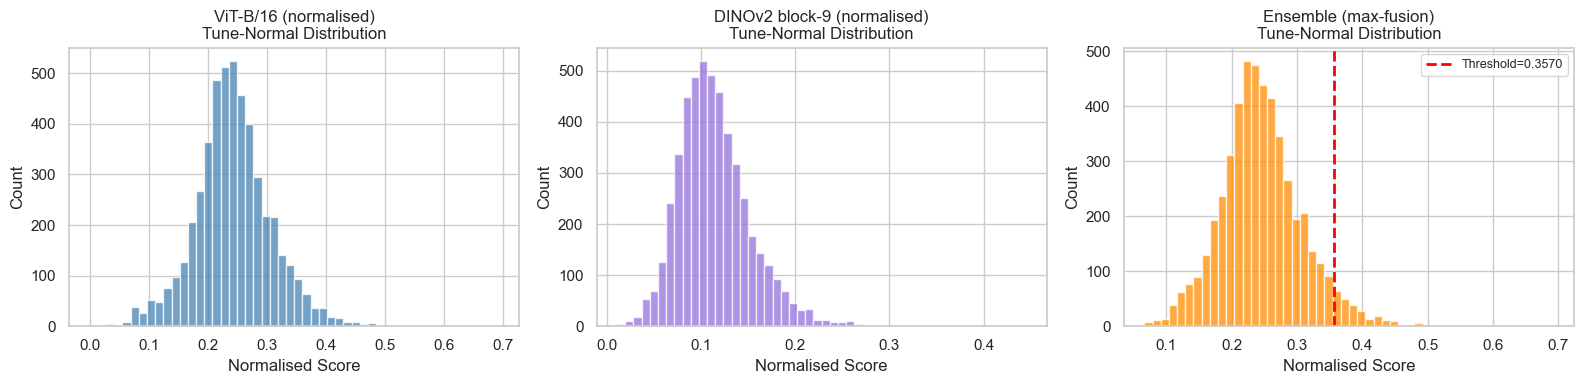

In [9]:
# -- 6. Threshold plot ---------------------------------------------------------
fpr_tune = float((ens_tune > best_thresh).mean())
print(f'Threshold : {best_thresh:.6f}  (q={THRESHOLD_QUANTILE})')
print(f'FPR on tune-normal: {fpr_tune:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, scores, name, color in [
    (axes[0], vit_tune_n,  'ViT-B/16 (normalised)',        'steelblue'),
    (axes[1], d2_tune_n,   f'DINOv2 block-{DINOV2_BLOCK} (normalised)', 'mediumpurple'),
    (axes[2], ens_tune,    'Ensemble (max-fusion)',         'darkorange'),
]:
    ax.hist(scores, bins=50, alpha=0.75, color=color)
    if ax is axes[2]:
        ax.axvline(best_thresh, color='red', linestyle='--', lw=2,
                   label=f'Threshold={best_thresh:.4f}')
        ax.legend(fontsize=9)
    ax.set_title(f'{name}\nTune-Normal Distribution')
    ax.set_xlabel('Normalised Score'); ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'threshold_selection.png'), dpi=140, bbox_inches='tight')
plt.show()

## Evaluate

Overall and per-class metrics for the ensemble. Individual model metrics are printed for direct comparison.

In [10]:
# -- 7. Evaluation -------------------------------------------------------------
all_scores = np.concatenate([ens_normal, ens_defect])
all_labels = np.concatenate([
    np.zeros(len(ens_normal), dtype=int),
    np.ones( len(ens_defect), dtype=int),
])
predictions = (all_scores > best_thresh).astype(int)

roc_auc = roc_auc_score(all_labels, all_scores)
auprc   = average_precision_score(all_labels, all_scores)
fpr_arr, tpr_arr, _         = roc_curve(all_labels, all_scores)
prec_arr, rec_arr, _        = precision_recall_curve(all_labels, all_scores)

f1_val        = f1_score(all_labels, predictions, pos_label=1, zero_division=0)
precision_val = precision_score(all_labels, predictions, pos_label=1, zero_division=0)
recall_val    = recall_score(all_labels, predictions, pos_label=1, zero_division=0)

print('── Ensemble Test Results ─────────────────────────────')
print(f'ROC-AUC  : {roc_auc:.4f}')
print(f'AUPRC    : {auprc:.4f}')
print(f'Threshold: {best_thresh:.6f}  (q={THRESHOLD_QUANTILE})')
print()
print(classification_report(all_labels, predictions,
                             target_names=['Normal', 'Defect'], digits=4))

# ── Per-class breakdown ───────────────────────────────────────────────────────
defect_preds = (ens_defect > best_thresh).astype(int)

print('── Per-class defect recall ───────────────────────────────────────')
print(f'  {"Defect type":<14}  {"N":>5}  {"Detected":>8}  {"Recall":>7}  {"Mean score":>10}')
print('  ' + '-' * 52)

perclass_results = {}
for cls in sorted(np.unique(defect_class_labels)):
    mask       = defect_class_labels == cls
    n          = mask.sum()
    detected   = defect_preds[mask].sum()
    recall     = detected / n
    mean_score = ens_defect[mask].mean()
    perclass_results[cls] = {
        'n': int(n), 'detected': int(detected),
        'recall': float(recall), 'mean_score': float(mean_score),
    }
    print(f'  {cls:<14}  {n:>5}  {detected:>8}  {recall:>6.1%}  {mean_score:>10.4f}')

overall_defect_recall = defect_preds.sum() / len(defect_preds)
print('  ' + '-' * 52)
print(f'  {"ALL DEFECTS":<14}  {len(defect_preds):>5}  {defect_preds.sum():>8}  {overall_defect_recall:>6.1%}')

── Ensemble Test Results ─────────────────────────────
ROC-AUC  : 0.9665
AUPRC    : 0.7165
Threshold: 0.356979  (q=0.95)

              precision    recall  f1-score   support

      Normal     0.9939    0.9524    0.9727      5000
      Defect     0.4815    0.8840    0.6234       250

    accuracy                         0.9491      5250
   macro avg     0.7377    0.9182    0.7981      5250
weighted avg     0.9695    0.9491    0.9561      5250

── Per-class defect recall ───────────────────────────────────────
  Defect type         N  Detected   Recall  Mean score
  ----------------------------------------------------
  Center             50        44   88.0%      0.4927
  Donut               7         7  100.0%      0.5201
  Edge-Loc           53        45   84.9%      0.4691
  Edge-Ring          84        75   89.3%      0.4583
  Loc                34        31   91.2%      0.4592
  Near-full           2         2  100.0%      0.4340
  Random              5         5  100.0%      0.4

## Comparison Table

All models side-by-side.

In [11]:
# -- 8. Comparison table -------------------------------------------------------

# ── Also evaluate each individual model at its own threshold for comparison ───
# ViT-B/16 at its own threshold (q=0.95 on its tune-normal normalised)
vit_thresh  = float(np.quantile(vit_tune_n, THRESHOLD_QUANTILE))
d2_thresh   = float(np.quantile(d2_tune_n,  THRESHOLD_QUANTILE))

def eval_model(normal_scores, defect_scores, thresh):
    all_s = np.concatenate([normal_scores, defect_scores])
    all_l = np.concatenate([np.zeros(len(normal_scores)), np.ones(len(defect_scores))])
    preds = (all_s > thresh).astype(int)
    return {
        'AUROC': roc_auc_score(all_l, all_s),
        'AUPRC': average_precision_score(all_l, all_s),
        'F1':    f1_score(all_l, preds, pos_label=1, zero_division=0),
    }

vit_m  = eval_model(vit_normal_n,  vit_defect_n,  vit_thresh)
d2_m   = eval_model(d2_normal_n,   d2_defect_n,   d2_thresh)
ens_m  = {'AUROC': roc_auc, 'AUPRC': auprc, 'F1': f1_val}

# ── Per-class recall for comparison ──────────────────────────────────────────
def perclass_recall(defect_scores, thresh):
    preds = (defect_scores > thresh).astype(int)
    out = {}
    for cls in sorted(np.unique(defect_class_labels)):
        mask = defect_class_labels == cls
        out[cls] = preds[mask].sum() / mask.sum()
    return out

vit_pc  = perclass_recall(vit_defect_n,  vit_thresh)
d2_pc   = perclass_recall(d2_defect_n,   d2_thresh)
ens_pc  = {c: v['recall'] for c, v in perclass_results.items()}

# ── Print table ───────────────────────────────────────────────────────────────
models = [
    (f'Frozen ViT-B/16 (reprod.)',     vit_m,  vit_pc),
    (f'DINOv2 block-{DINOV2_BLOCK}',  d2_m,   d2_pc),
    (f'Ensemble (max-fusion)',          ens_m,  ens_pc),
]

all_classes = sorted(np.unique(defect_class_labels))

header = f'{"Model":<32}  {"AUROC":>7}  {"AUPRC":>7}  {"F1":>7}  '
header += '  '.join(f'{c[:8]:>8}' for c in all_classes)
print(header)
print('-' * len(header))
for name, m, pc in models:
    row = f'{name:<32}  {m["AUROC"]:>7.4f}  {m["AUPRC"]:>7.4f}  {m["F1"]:>7.4f}  '
    row += '  '.join(f'{pc.get(c, float("nan")):>8.3f}' for c in all_classes)
    print(row)

# ── DataFrame version ─────────────────────────────────────────────────────────
rows = []
for name, m, pc in models:
    row = {'Model': name, **m, **{c: round(pc.get(c, float('nan')), 3) for c in all_classes}}
    rows.append(row)
compare_df = pd.DataFrame(rows).set_index('Model')
display(compare_df.round(4))

compare_df.to_csv(os.path.join(RESULTS_DIR, 'model_comparison.csv'))
print(f'Comparison table saved -> {RESULTS_DIR}/model_comparison.csv')

Model                               AUROC    AUPRC       F1    Center     Donut  Edge-Loc  Edge-Rin       Loc  Near-ful    Random   Scratch
-------------------------------------------------------------------------------------------------------------------------------------------
Frozen ViT-B/16 (reprod.)          0.9563   0.6709   0.5951     0.820     1.000     0.792     0.893     0.794     1.000     0.800     0.667
DINOv2 block-9                     0.9147   0.5609   0.4921     0.560     1.000     0.547     0.738     0.706     1.000     1.000     0.933
Ensemble (max-fusion)              0.9665   0.7165   0.6234     0.880     1.000     0.849     0.893     0.912     1.000     1.000     0.800


,AUROC,AUPRC,F1,Center,Donut,Edge-Loc,Edge-Ring,Loc,Near-full,Random,Scratch
Model,,,,,,,,,,,
Frozen ViT-B/16 (reprod.),0.9563,0.6709,0.5951,0.82,1.0,0.792,0.893,0.794,1.0,0.8,0.667
DINOv2 block-9,0.9147,0.5609,0.4921,0.56,1.0,0.547,0.738,0.706,1.0,1.0,0.933
Ensemble (max-fusion),0.9665,0.7165,0.6234,0.88,1.0,0.849,0.893,0.912,1.0,1.0,0.800


Comparison table saved -> C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\dinov2_vit_b14\x224\ensemble_block9\artifacts\results/model_comparison.csv


## Evaluation Plots

In [ ]:
# -- 9. Evaluation plots -------------------------------------------------------
fig = plt.figure(figsize=(22, 10))
gs  = fig.add_gridspec(2, 4, hspace=0.4, wspace=0.35)

ax_dist = fig.add_subplot(gs[0, 0])
ax_roc  = fig.add_subplot(gs[0, 1])
ax_pr   = fig.add_subplot(gs[0, 2])
ax_cm   = fig.add_subplot(gs[0, 3])
ax_pc   = fig.add_subplot(gs[1, :])

# Score distributions
ax_dist.hist(ens_normal, bins=50, alpha=0.7, color='steelblue', label='Normal')
ax_dist.hist(ens_defect, bins=50, alpha=0.7, color='tomato',    label='Defect')
ax_dist.axvline(best_thresh, color='black', linestyle='--',
                label=f'Threshold={best_thresh:.4f}')
ax_dist.set_title('Ensemble Score Distributions')
ax_dist.set_xlabel('Max-fused Score'); ax_dist.set_ylabel('Count'); ax_dist.legend(fontsize=9)

# ROC curve: ensemble vs individual models
for scores_n, scores_d, label, color, ls in [
    (ens_normal,  ens_defect,  f'Ensemble  AUC={roc_auc:.4f}',     'darkorange',   '-'),
    (vit_normal_n, vit_defect_n, f'ViT-B/16  AUC={vit_m["AUROC"]:.4f}', 'steelblue', '--'),
    (d2_normal_n,  d2_defect_n,  f'DINOv2 b{DINOV2_BLOCK}  AUC={d2_m["AUROC"]:.4f}', 'mediumpurple', ':'),
]:
    all_s = np.concatenate([scores_n, scores_d])
    all_l = np.concatenate([np.zeros(len(scores_n)), np.ones(len(scores_d))])
    fpr_i, tpr_i, _ = roc_curve(all_l, all_s)
    ax_roc.plot(fpr_i, tpr_i, color=color, lw=2, linestyle=ls, label=label)
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax_roc.set_title('ROC Curves')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR'); ax_roc.legend(fontsize=8)

# PR curve: ensemble vs individual
baseline_pr = all_labels.mean()
for scores_n, scores_d, label, color, ls in [
    (ens_normal,  ens_defect,  f'Ensemble  AUPRC={auprc:.4f}',          'darkorange',   '-'),
    (vit_normal_n, vit_defect_n, f'ViT-B/16  AUPRC={vit_m["AUPRC"]:.4f}', 'steelblue', '--'),
    (d2_normal_n,  d2_defect_n,  f'DINOv2 b{DINOV2_BLOCK}  AUPRC={d2_m["AUPRC"]:.4f}', 'mediumpurple', ':'),
]:
    all_s = np.concatenate([scores_n, scores_d])
    all_l = np.concatenate([np.zeros(len(scores_n)), np.ones(len(scores_d))])
    p_i, r_i, _ = precision_recall_curve(all_l, all_s)
    ax_pr.plot(r_i, p_i, color=color, lw=2, linestyle=ls, label=label)
ax_pr.axhline(baseline_pr, color='gray', linestyle='--', lw=1, label=f'No-skill={baseline_pr:.3f}')
ax_pr.set_title('Precision-Recall Curves')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1.02); ax_pr.legend(fontsize=8)

# Confusion matrix
cm = confusion_matrix(all_labels, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Normal', 'Pred Defect'],
            yticklabels=['True Normal', 'True Defect'], ax=ax_cm)
ax_cm.set_title('Ensemble Confusion Matrix')

# Per-class recall comparison (grouped bars)
classes     = all_classes
x           = np.arange(len(classes))
width       = 0.26

ens_recs = [ens_pc.get(c, 0)       for c in classes]
vit_recs = [vit_pc.get(c, 0)       for c in classes]
d2_recs  = [d2_pc.get(c, 0)        for c in classes]

ax_pc.bar(x - width, vit_recs,  width, label=f'ViT-B/16',          color='steelblue',   alpha=0.85)
ax_pc.bar(x,         d2_recs,   width, label=f'DINOv2 b{DINOV2_BLOCK}', color='mediumpurple', alpha=0.85)
ax_pc.bar(x + width, ens_recs,  width, label='Ensemble',            color='darkorange',  alpha=0.85)

ax_pc.set_xticks(x); ax_pc.set_xticklabels(classes, rotation=0)
ax_pc.set_ylim(0, 1.18); ax_pc.set_ylabel('Detection Recall')
ax_pc.set_title('Per-Class Defect Recall: ViT-B/16 vs DINOv2 vs Ensemble')
ax_pc.axhline(0.8, color='gray', linestyle=':', lw=1, alpha=0.6)
ax_pc.legend(fontsize=10)

for i, (vr, dr, er) in enumerate(zip(vit_recs, d2_recs, ens_recs)):
    for offset, val in [(-width, vr), (0, dr), (width, er)]:
        ax_pc.text(i + offset, val + 0.02, f'{val:.0%}', ha='center', va='bottom', fontsize=7.5)

plt.suptitle(
    f'PatchCore Ensemble (ViT-B/16 + DINOv2 block-{DINOV2_BLOCK} max-fusion)  |  '
    f'ROC-AUC={roc_auc:.4f}  |  AUPRC={auprc:.4f}  |  F1={f1_val:.4f}',
    fontsize=13, fontweight='bold',
)
plt.savefig(os.path.join(PLOTS_DIR, 'evaluation_results.png'), dpi=130, bbox_inches='tight')
plt.show()

# Save defect recall CSV
defect_recall_df = pd.DataFrame([
    {'failure_label': c, **v} for c, v in perclass_results.items()
]).sort_values('recall').reset_index(drop=True)
defect_recall_df.to_csv(os.path.join(RESULTS_DIR, 'defect_recall.csv'), index=False)
display(defect_recall_df)

## UMAP Visualization

Projects ensemble scores into 2D using UMAP on the concatenated normalised score vectors `[vit_norm, dinov2_norm]` for each test image. This shows how the two models' signals combine in score space.

In [ ]:
# -- 10. UMAP on 2D score space ------------------------------------------------
if (not FORCE_RERUN_UMAP) and os.path.exists(UMAP_PNG_PATH):
    print(f'Displaying saved UMAP: {UMAP_PNG_PATH}')
    display(IPImage(filename=UMAP_PNG_PATH))
else:
    try:
        import umap.umap_ as umap_lib
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'umap-learn', '-q'])
        import umap.umap_ as umap_lib

    # 2-D feature: [normalised_vit_score, normalised_dinov2_score] per image
    X_normal = np.column_stack([vit_normal_n, d2_normal_n])  # [5000, 2]
    X_defect = np.column_stack([vit_defect_n, d2_defect_n])  # [250,  2]

    # Subsample normals to balance
    MAX_NORMAL_UMAP = 1000
    idx_n = np.random.choice(len(X_normal), min(MAX_NORMAL_UMAP, len(X_normal)), replace=False)
    X = np.concatenate([X_normal[idx_n], X_defect])
    y = np.concatenate([np.zeros(len(idx_n)), np.ones(len(X_defect))]).astype(int)
    y_class = np.concatenate([
        np.array(['Normal'] * len(idx_n)),
        defect_class_labels,
    ])

    reducer = umap_lib.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                            metric='euclidean', random_state=SEED, transform_seed=SEED,
                            low_memory=True, verbose=False)
    coords = reducer.fit_transform(X)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: normal vs defect
    m0, m1 = (y == 0), (y == 1)
    axes[0].scatter(coords[m0, 0], coords[m0, 1], s=10, alpha=0.4,
                    c='steelblue', label=f'Normal (n={m0.sum()})', linewidths=0)
    axes[0].scatter(coords[m1, 0], coords[m1, 1], s=15, alpha=0.7,
                    c='tomato', label=f'Defect (n={m1.sum()})', linewidths=0)
    axes[0].set_title('UMAP: Normal vs Defect (ensemble score space)')
    axes[0].set_xlabel('UMAP-1'); axes[0].set_ylabel('UMAP-2'); axes[0].legend(fontsize=9)

    # Right: per-class
    palette = sns.color_palette('tab10', n_colors=len(np.unique(y_class[y == 1])))
    axes[1].scatter(coords[m0, 0], coords[m0, 1], s=8, alpha=0.3,
                    c='lightgray', label='Normal', linewidths=0)
    for col, cls in zip(palette, sorted(np.unique(y_class[y == 1]))):
        mask_cls = (y_class == cls)
        axes[1].scatter(coords[mask_cls, 0], coords[mask_cls, 1],
                        s=18, alpha=0.8, c=[col], label=cls, linewidths=0)
    axes[1].set_title('UMAP: Per-class defect (ensemble score space)')
    axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')
    axes[1].legend(fontsize=8, loc='best')

    plt.tight_layout()
    fig.savefig(UMAP_PNG_PATH, dpi=160, bbox_inches='tight')
    plt.show()

    pd.DataFrame({
        'umap_1': coords[:, 0], 'umap_2': coords[:, 1],
        'label': y, 'class': y_class,
    }).to_csv(UMAP_CSV_PATH, index=False)
    print(f'UMAP saved: {UMAP_PNG_PATH}')

## Save Artifacts

In [ ]:
# -- 11. Save artifacts --------------------------------------------------------
np.savez_compressed(
    SCORES_EXPORT_PATH,
    tune_normal_scores  = ens_tune,
    test_normal_scores  = ens_normal,
    test_defect_scores  = ens_defect,
    vit_tune_norm       = vit_tune_n,
    vit_normal_norm     = vit_normal_n,
    vit_defect_norm     = vit_defect_n,
    d2_tune_norm        = d2_tune_n,
    d2_normal_norm      = d2_normal_n,
    d2_defect_norm      = d2_defect_n,
    threshold           = np.array(best_thresh),
)
print(f'Scores saved -> {SCORES_EXPORT_PATH}')

metrics = dict(
    ensemble_method      = 'max_fusion_minmax_norm',
    dinov2_block         = DINOV2_BLOCK,
    roc_auc              = float(roc_auc),
    auprc                = float(auprc),
    f1_defect            = float(f1_val),
    precision_defect     = float(precision_val),
    recall_defect        = float(recall_val),
    threshold            = float(best_thresh),
    threshold_quantile   = float(THRESHOLD_QUANTILE),
    confusion_matrix     = cm.tolist(),
    n_test_normal        = int(len(ens_normal)),
    n_test_defect        = int(len(ens_defect)),
    per_class            = perclass_results,
)
with open(METRICS_EXPORT_PATH, 'w') as fh:
    json.dump(metrics, fh, indent=2)
print(f'Metrics saved -> {METRICS_EXPORT_PATH}')

print(f'\nROC-AUC : {roc_auc:.4f}')
print(f'AUPRC   : {auprc:.4f}')
print(f'F1      : {f1_val:.4f}')

## Cleanup

In [ ]:
# -- 12. Cleanup ---------------------------------------------------------------
for name in [
    'vit_tune', 'vit_normal', 'vit_defect',
    'd2_tune', 'd2_normal', 'd2_defect',
    'vit_tune_n', 'vit_normal_n', 'vit_defect_n',
    'd2_tune_n', 'd2_normal_n', 'd2_defect_n',
    'ens_tune', 'ens_normal', 'ens_defect',
    'all_scores', 'all_labels', 'predictions',
    'test_defect_df', 'defect_class_labels',
]:
    if name in globals():
        del globals()[name]
gc.collect()
print('Cleared.')